### [문제] 타이타닉 폴더에 있는 train.csv파일을 사용하여 아래 문제에 대한 답을 작성하시오.
<처리조건>
 matplotlib 라이브러리를 사용한다.

In [1]:
import pandas as pd

df = pd.read_csv('./titanic/train.csv')
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### (1) Survived 컬럼의 생존자와 사망자 수를 구하여 막대 그래프로 나타내시오.

<function matplotlib.pyplot.show(close=None, block=None)>

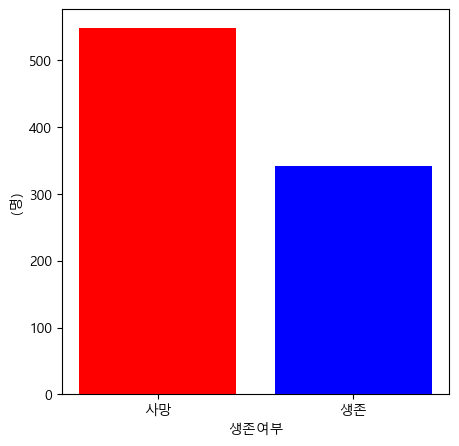

In [2]:
import matplotlib.pyplot as plt

df2 = df.groupby("Survived").size()
plt.rc('font', family = 'Malgun Gothic')
plt.rc('axes', unicode_minus = False)

survived = ['사망','생존']
serv2 = df2
c= ['red', 'blue']


plt.figure(figsize = (5,5))
plt.bar(survived , serv2, color = c)
plt.xlabel("생존여부")
plt.ylabel("(명)")

plt.show

### (2) Survived 컬럼의 생존자와 사망자 수를 등급별로 구하여 누적막대그래프로 나타내시오. 등급을 누적으로 나타낸다.

In [3]:
df3 = df.groupby(["Pclass", "Survived"]).size()
df4 = pd.DataFrame(df3)
df5 = df4.reset_index()
df6 = df5.set_index('Pclass')
df6

,Survived,0
Pclass,,
1,0,80
1,1,136
2,0,97
2,1,87
3,0,372
3,1,119


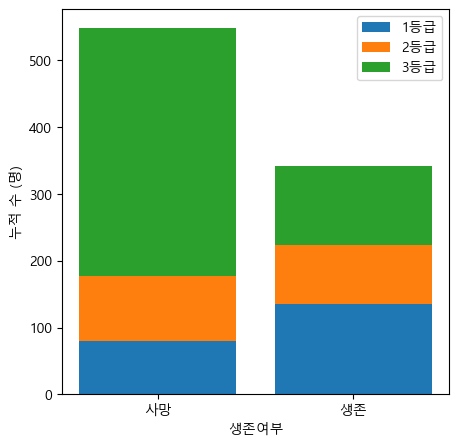

In [4]:
x = ['사망','생존']
y = df6[0][1].values
y1= df6[0][2].values
y2= df6[0][3].values


plt.figure(figsize = (5,5))
plt.bar(x,y, label = '1등급')
plt.bar(x,y1,bottom = y, label = '2등급')
plt.bar(x, y2 ,bottom = y + y1 , label = '3등급')
plt.xlabel('생존여부')
plt.ylabel('누적 수 (명)')

plt.legend()
plt.show()

### (3) Embarked 컬럼의 탑승지역의 분포를 파이차트로 나타내는데 각 탑승지역에 해당하는 비율을 파이차트에 출력하시오.

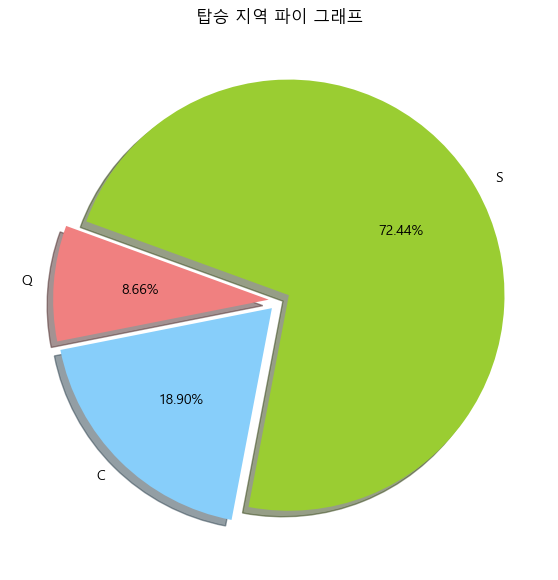

In [5]:
embarked = df['Embarked'].dropna().value_counts()

explode = [0.05,0.05,0.05]
colors = ['yellowgreen', 'lightskyblue','lightcoral']

plt.figure(figsize=(7, 7))  # 그래프 크기
plt.pie(embarked, labels=embarked.index, autopct='%1.2f%%', startangle=160, 
        colors=colors, shadow = True, explode= explode, counterclock = False) 

plt.title('탑승 지역 파이 그래프')
plt.show()

### (4) Age컬럼을 10대미만, 10대, 20대, 30대, 40대, 50대, 60대, 70대, 80대 구간으로 나누어 히스트그램을 나타내시오.

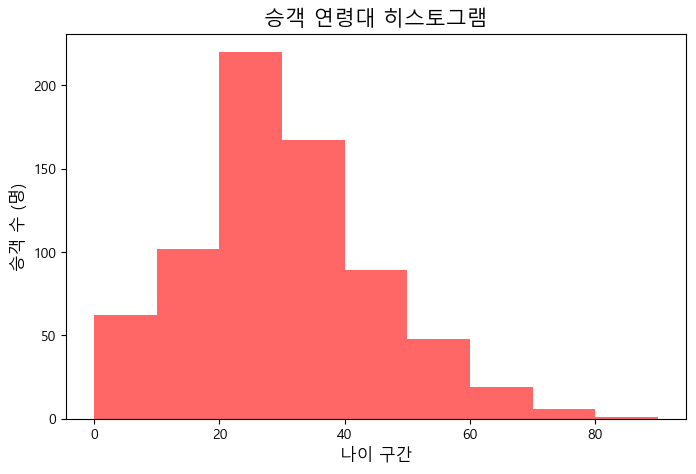

In [6]:
plt.figure(figsize=(8, 5))

age = df['Age'].dropna()

plt.hist(age, bins=range(0, 91, 10), rwidth=1, color='red', alpha=0.6)
  
plt.title('승객 연령대 히스토그램', fontsize=15)
plt.xlabel('나이 구간', fontsize=12)
plt.ylabel('승객 수 (명)', fontsize=12)

plt.show()